## Importing Libraries and Loading Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import LabelEncoder
from scipy.linalg import lu

data = pd.read_csv("academic_scores.csv")
print(data.shape)
data.head()

(200, 8)


,ID,Physics,Chemistry,Biology,Geography,Arts,Total_Score,Performance
0,S001,61,94,75,89,56,375,High
1,S002,74,53,82,49,63,321,Low
2,S003,64,48,35,75,40,262,Low
3,S004,96,97,46,43,97,379,High
4,S005,90,72,64,65,86,377,High


---
## Part A - Vector and Matrix Fundamentals

### 1. Representing each student's subject scores as a vector

In [2]:
cols = ["Physics", "Chemistry", "Biology", "Geography", "Arts"]

s1 = np.array(data[cols].iloc[0])
s2 = np.array(data[cols].iloc[1])

print("Student S001 score vector:", s1)
print("Student S002 score vector:", s2)

Student S001 score vector: [61 94 75 89 56]
Student S002 score vector: [74 53 82 49 63]


### 2. Norm-1 and Norm-2 of vectors

In [3]:
s1_n1 = np.linalg.norm(s1, ord=1)
s1_n2 = np.linalg.norm(s1, ord=2)

s2_n1 = np.linalg.norm(s2, ord=1)
s2_n2 = np.linalg.norm(s2, ord=2)

print("S001 - Norm 1:", s1_n1)
print("S001 - Norm 2:", s1_n2)
print()
print("S002 - Norm 1:", s2_n1)
print("S002 - Norm 2:", s2_n2)

S001 - Norm 1: 375.0
S001 - Norm 2: 170.99415194678443

S002 - Norm 1: 321.0
S002 - Norm 2: 146.21559424356897


### 3. Dot Product and Angle between two student score vectors

In [4]:
dp = np.dot(s1, s2)
print("Dot Product (S001 . S002):", dp)

cos_val = dp / (np.linalg.norm(s1) * np.linalg.norm(s2))
theta = np.degrees(np.arccos(cos_val))
print("Angle between S001 and S002:", theta, "degrees")

Dot Product (S001 . S002): 23535
Angle between S001 and S002: 19.72484892169634 degrees


### 4. Cross Product (using Physics, Chemistry, Biology - first 3 subjects)

In [5]:
s1_3d = s1[:3]
s2_3d = s2[:3]

cp = np.cross(s1_3d, s2_3d)
print("S001 3D vector:", s1_3d)
print("S002 3D vector:", s2_3d)
print("Cross Product result:", cp)

S001 3D vector: [61 94 75]
S002 3D vector: [74 53 82]
Cross Product result: [ 3733   548 -3723]


### 5. Projection of S001 vector onto S002 vector

In [6]:
proj = (np.dot(s1, s2) / np.dot(s2, s2)) * s2
print("Projection of S001 onto S002:")
print(proj)

Projection of S001 onto S002:
[81.46265026 58.34487114 90.26942327 53.94148463 69.35333739]


---
## Part B - Matrix Operations

### 4. Student Score Matrix (first 5 students x 5 subjects)

In [7]:
score_matrix = data[cols].head(5).values
print("Score Matrix (5x5):")
print(score_matrix)

Score Matrix (5x5):
[[61 94 75 89 56]
 [74 53 82 49 63]
 [64 48 35 75 40]
 [96 97 46 43 97]
 [90 72 64 65 86]]


### Matrix Addition and Multiplication

In [8]:
mat_a = data[cols].iloc[0:5].values
mat_b = data[cols].iloc[5:10].values

mat_add = mat_a + mat_b
print("Matrix Addition:")
print(mat_add)

mat_mul = np.dot(mat_a, mat_b.T)
print()
print("Matrix Multiplication (mat_a x mat_b.T):")
print(mat_mul)

Matrix Addition:
[[133 132 161 172 154]
 [142 125 165  91 112]
 [153 132 132 159 116]
 [166 151 133  85 135]
 [171 125 142 152 168]]

Matrix Multiplication (mat_a x mat_b.T):
[[27289 23623 32332 21737 28108]
 [24635 20799 27896 19628 24628]
 [19587 15823 22463 14787 20263]
 [27629 23889 32138 21452 28200]
 [28543 23560 32262 21754 28805]]


### Transpose of the Score Matrix

In [9]:
mat_T = score_matrix.T
print("Original Shape:", score_matrix.shape)
print("Transposed Shape:", mat_T.shape)
print()
print("Transposed Matrix:")
print(mat_T)

Original Shape: (5, 5)
Transposed Shape: (5, 5)

Transposed Matrix:
[[61 74 64 96 90]
 [94 53 48 97 72]
 [75 82 35 46 64]
 [89 49 75 43 65]
 [56 63 40 97 86]]


### Determinant and Inverse

In [10]:
det_val = np.linalg.det(score_matrix)
print("Determinant:", det_val)

if abs(det_val) > 1e-6:
    mat_inv = np.linalg.inv(score_matrix)
    print()
    print("Inverse Matrix:")
    print(mat_inv)
else:
    print("Matrix is singular - inverse not possible")

Determinant: -152868090.0

Inverse Matrix:
[[-0.02244174  0.0362217   0.04143725  0.02829408 -0.06310751]
 [ 0.01255722  0.00514306  0.00259111  0.02339565 -0.03953767]
 [ 0.00481089  0.02098375 -0.00962515 -0.00584919 -0.00743034]
 [ 0.00646565 -0.02203307  0.00213015 -0.02089288  0.03450477]
 [ 0.00450549 -0.04117515 -0.03998097 -0.02905313  0.09022232]]


---
## Part C - Linear Transformations and Geometry

### 5. Line, Plane and Hyperplane with dataset

In [11]:
print("Line (1D) - Physics scores of first 5 students:")
print(data["Physics"].head(5).values)

print()
print("Plane (2D) - Physics and Chemistry scores:")
print(data[["Physics", "Chemistry"]].head(5).values)

print()
print("Hyperplane (5D) - All subject scores:")
print(data[cols].head(5).values)

Line (1D) - Physics scores of first 5 students:
[61 74 64 96 90]

Plane (2D) - Physics and Chemistry scores:
[[61 94]
 [74 53]
 [64 48]
 [96 97]
 [90 72]]

Hyperplane (5D) - All subject scores:
[[61 94 75 89 56]
 [74 53 82 49 63]
 [64 48 35 75 40]
 [96 97 46 43 97]
 [90 72 64 65 86]]


### 6. Dimensionality from 2D to 3D to 5D

In [12]:
print("2D - Physics and Chemistry:")
print(data[["Physics", "Chemistry"]].head(3).values)

print()
print("3D - Adding Biology as third dimension:")
print(data[["Physics", "Chemistry", "Biology"]].head(3).values)

print()
print("5D - All 5 subjects (hyperplane):")
print(data[cols].head(3).values)

print()
print("Each new subject adds one more dimension to the data.")

2D - Physics and Chemistry:
[[61 94]
 [74 53]
 [64 48]]

3D - Adding Biology as third dimension:
[[61 94 75]
 [74 53 82]
 [64 48 35]]

5D - All 5 subjects (hyperplane):
[[61 94 75 89 56]
 [74 53 82 49 63]
 [64 48 35 75 40]]

Each new subject adds one more dimension to the data.


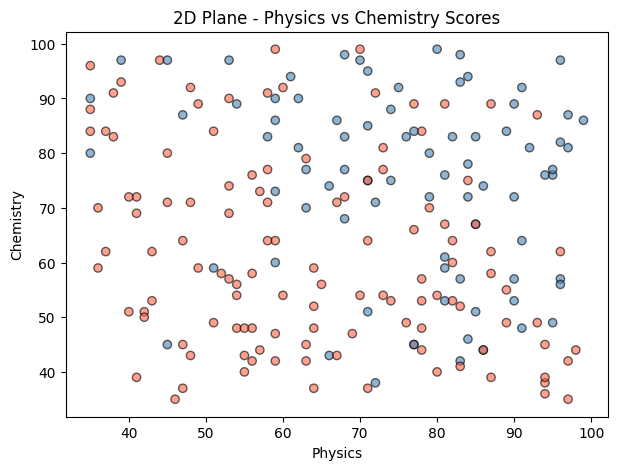

In [13]:
# Visualizing 2D plane of Physics vs Chemistry
plt.figure(figsize=(7, 5))
colors = ["steelblue" if p == "High" else "tomato" for p in data["Performance"]]
plt.scatter(data["Physics"], data["Chemistry"], c=colors, edgecolors="black", alpha=0.6)
plt.title("2D Plane - Physics vs Chemistry Scores")
plt.xlabel("Physics")
plt.ylabel("Chemistry")
plt.show()

---
## Part D - Eigenvalues and Decomposition

### 7. Eigenvalues and Eigenvectors of Covariance Matrix

In [14]:
cov_mat = np.cov(data[cols].values.T)

eig_vals, eig_vecs = np.linalg.eig(cov_mat)

print("Covariance Matrix Shape:", cov_mat.shape)
print()
print("Eigenvalues:")
print(eig_vals)
print()
print("Eigenvectors:")
print(eig_vecs)

Covariance Matrix Shape: (5, 5)

Eigenvalues:
[269.90802931 300.76417141 332.15385473 373.30481849 409.70980445]

Eigenvectors:
[[ 0.51735618  0.47628034 -0.48483212 -0.51801608  0.0457907 ]
 [ 0.40049644  0.47653835  0.05843592  0.77816389 -0.05966583]
 [-0.28326024 -0.07205142 -0.61704732  0.28773962  0.67158822]
 [-0.63284643  0.44304385 -0.33155219  0.03786629 -0.54023776]
 [ 0.30201692 -0.58701702 -0.52043137  0.20467625 -0.50145351]]


### 8. LU Decomposition

In [15]:
m = data[cols].head(5).values.astype(float)

P, L, U = lu(m)

print("Original Matrix:")
print(m)
print()
print("L (Lower Triangular):")
print(L)
print()
print("U (Upper Triangular):")
print(U)

Original Matrix:
[[61. 94. 75. 89. 56.]
 [74. 53. 82. 49. 63.]
 [64. 48. 35. 75. 40.]
 [96. 97. 46. 43. 97.]
 [90. 72. 64. 65. 86.]]

L (Lower Triangular):
[[ 1.          0.          0.          0.          0.        ]
 [ 0.63541667  1.          0.          0.          0.        ]
 [ 0.77083333 -0.67267461  1.          0.          0.        ]
 [ 0.66666667 -0.51496621  0.36083757  1.          0.        ]
 [ 0.9375     -0.58513035  0.61627529  0.4431383   1.        ]]

U (Upper Triangular):
[[ 96.          97.          46.          43.          97.        ]
 [  0.          32.36458333  45.77083333  61.67708333  -5.63541667]
 [  0.           0.          77.33054393  57.34277438 -15.56163502]
 [  0.           0.           0.          57.40351943 -21.95349321]
 [  0.           0.           0.           0.          11.08373162]]


### 9. Singular Value Decomposition (SVD)

In [16]:
scores = data[cols].values.astype(float)

U_m, S_vals, Vt_m = np.linalg.svd(scores, full_matrices=False)

print("Singular Values:", S_vals)
print()
print("U shape:", U_m.shape)
print("Vt shape:", Vt_m.shape)
print()
print("Top singular value explains the most variance in the data")

Singular Values: [2134.62945879  284.71267354  270.50247628  246.30106158  232.27777463]

U shape: (200, 5)
Vt shape: (5, 5)

Top singular value explains the most variance in the data


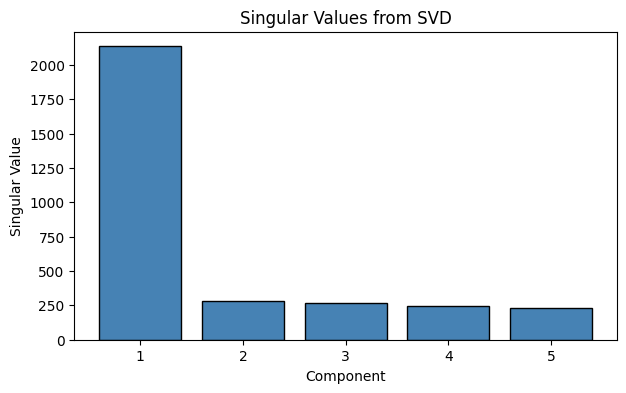

In [17]:
# Visualizing singular values
plt.figure(figsize=(7, 4))
plt.bar(range(1, len(S_vals)+1), S_vals, color="steelblue", edgecolor="black")
plt.title("Singular Values from SVD")
plt.xlabel("Component")
plt.ylabel("Singular Value")
plt.show()

---
## Part E - Dimensionality Reduction

### 10. PCA - Reducing 5 subjects to 2 dimensions

In [18]:
scores = data[cols].values

pca_model = PCA(n_components=2)
pca_scores = pca_model.fit_transform(scores)

print("Before PCA:", scores.shape)
print("After PCA:", pca_scores.shape)
print()
print("Variance Explained:", pca_model.explained_variance_ratio_)
print("Total:", sum(pca_model.explained_variance_ratio_))

Before PCA: (200, 5)
After PCA: (200, 2)

Variance Explained: [0.24302997 0.22143541]
Total: 0.464465375034198


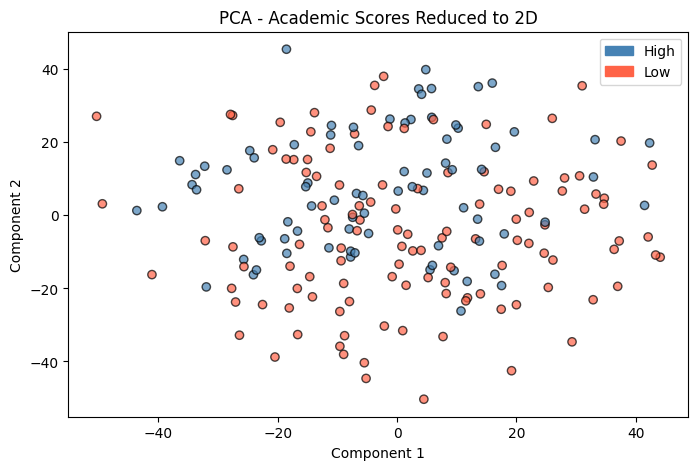

In [19]:
# PCA scatter plot
plt.figure(figsize=(8, 5))
clrs = ["steelblue" if p == "High" else "tomato" for p in data["Performance"]]
plt.scatter(pca_scores[:, 0], pca_scores[:, 1], c=clrs, edgecolors="black", alpha=0.7)
plt.title("PCA - Academic Scores Reduced to 2D")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

import matplotlib.patches as mpatches
h = mpatches.Patch(color="steelblue", label="High")
l = mpatches.Patch(color="tomato", label="Low")
plt.legend(handles=[h, l])
plt.show()

### 11. LDA - Classifying students into High and Low performance

In [20]:
enc = LabelEncoder()
lbs = enc.fit_transform(data["Performance"])

lda_model = LDA(n_components=1)
lda_scores = lda_model.fit_transform(scores, lbs)

print("Before LDA:", scores.shape)
print("After LDA:", lda_scores.shape)
print()
print("Classes:", enc.classes_)

Before LDA: (200, 5)
After LDA: (200, 1)

Classes: ['High' 'Low']


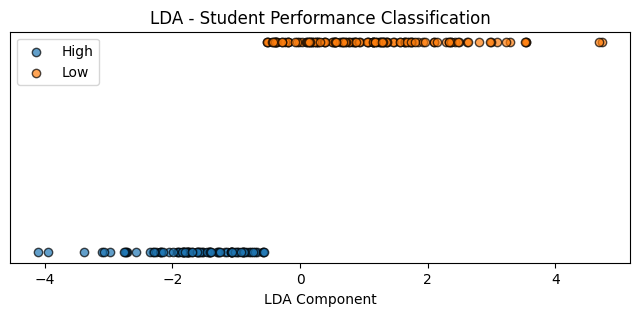

In [21]:
# LDA result plot
plt.figure(figsize=(8, 3))
for i, cat in enumerate(enc.classes_):
    idx = data["Performance"] == cat
    plt.scatter(lda_scores[idx], np.zeros(idx.sum()) + i * 0.1,
                label=cat, alpha=0.7, edgecolors="black")
plt.title("LDA - Student Performance Classification")
plt.xlabel("LDA Component")
plt.yticks([])
plt.legend()
plt.show()